-------------------------------------------
# **1.Importação das Bibliotecas e Leitura dos Dados**

* Neste parte, importamos as bibliotecas necessárias para a construção e avaliação do modelo de aprendizado de máquina de classificação.

* Estamos usando:
 * Pandas: Para manipulação de dados;

 * Scikit-Learn: Para o pré-processamento e construção do modelo;

 * Cosine_Similarity para calcular a similaridade entre descrições de problemas.

* Carregamos os dados do arquivo CSV e verificamos quais colunas estão disponíveis no DataFrame. As colunas principais que utilizamos são:

    * Descricao: A descrição do problema *(As descrições foram escritas quase iguais a como um usuário descreveria o problema em seu carro)*
    * Problema: A categoria do problema *(O Possivel "Diagnóstico" do problema descrito pelo usuário.)*
    * Solucao: A solução correspondente. *(Solução baseada no problema e descrição)*




In [20]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv('/content/DiagnosCAR-DATASET.csv', sep=',', usecols=['Descricao', 'Problema', 'Solucao'])

print(f"Colunas: {df.columns}\n")
print("Mostrando os 5 itens do dataset")
display(df.head())

Colunas: Index(['Descricao', 'Problema', 'Solucao'], dtype='object')

Mostrando os 5 itens do dataset


,Descricao,Problema,Solucao
0,meu carro não liga,problema no motor,Verificar bateria e sistema de ignição; se per...
1,o motor está fazendo barulho estranho,problema no motor,Verificar nível de óleo e filtro; se o barulho...
2,percebo um cheiro de gasolina ao ligar o carro,problema no motor,Verificar vazamento no sistema de combustível;...
3,o motor treme muito quando acelero,problema no motor,Verificar velas e injetores; se o problema per...
4,o carro perde potência ao subir uma ladeira,problema no motor,Verificar filtro de ar e sistema de combustão;...


-------------------------------------------
# **2.Divisão dos Dados em Conjunto de Treino e Teste**


*   Neste bloco, dividimos os dados em conjuntos de treino e teste.
  *    'X' representa as descrições dos problemas;
  *    'Y' representa os rótulos dos problemas.
*  Usamos 80% dos dados para treino e 20% para teste.

In [22]:
X = df['Descricao']
y = df['Problema']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

-------------------------------------------
# **3.Criação do Modelo de TF-IDF**


*   Aqui transformamos as descrições em vetores TF-IDF. O `TfidfVectorizer` converte o texto em uma representação numérica que considera a importância de cada palavra em relação ao documento e ao corpus.


In [23]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

-------------------------------------------
# **4.Treinando o Classificador**

*   Usamos o `RandomForestClassifier` para treinar um modelo de classificação que prevê o tipo de problema com base na descrição.



In [24]:
classifier = RandomForestClassifier()
classifier.fit(X_train_tfidf, y_train)

RandomForestClassifier()

---
# **5.Fazer Previsões e Avaliar o Modelo**

*   Aqui, fazemos previsões no conjunto de teste e avaliamos a acurácia do modelo. O `classification_report` fornece métricas como precisão, recall e F1-score para cada categoria de problema.



In [25]:
y_pred = classifier.predict(X_test_tfidf)
print("Acurácia:", accuracy_score(y_test, y_pred) * 100)
print("Relatório de Classificação:\n", classification_report(y_test, y_pred))

Acurácia: 68.96551724137932
Relatório de Classificação:
                                   precision    recall  f1-score   support

             problema na direção       0.67      0.33      0.44         6
           problema na embreagem       0.80      0.67      0.73         6
              problema na marcha       0.83      0.83      0.83         6
               problema no motor       0.45      1.00      0.62         5
problema relacionado ao conforto       1.00      0.67      0.80         6

                        accuracy                           0.69        29
                       macro avg       0.75      0.70      0.69        29
                    weighted avg       0.76      0.69      0.69        29



---

# **6.Matriz de Confusão com Porcentagens**

A matriz de confusão nos ajuda a visualizar onde o modelo está acertando e errando. Aqui, representamos a matriz de confusão com porcentagens, o que facilita a interpretação das previsões corretas e incorretas para cada classe.

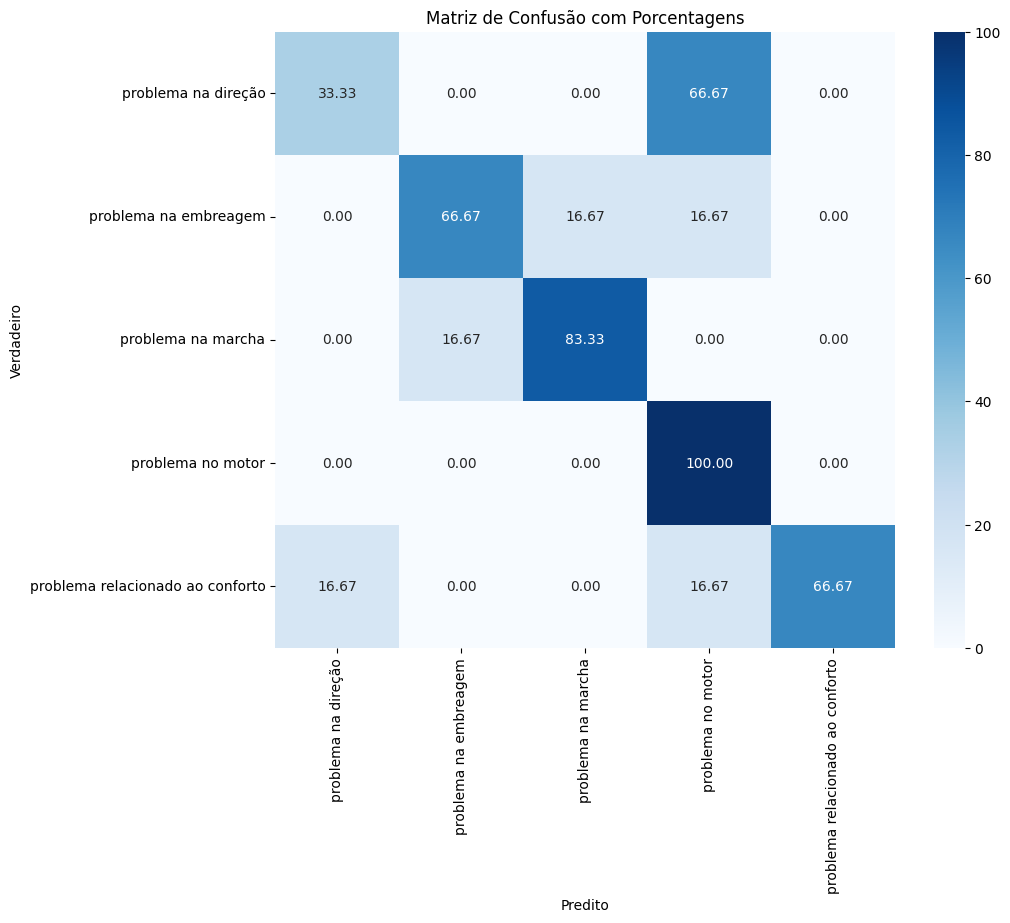

In [33]:
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_percent, annot=True, fmt=".2f", cmap="Blues", xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.title("Matriz de Confusão com Porcentagens")
plt.show()

---

# **8.Salvamento do modelo**
* Salvamos o classificador treinado e o vetor TF-IDF em um arquivo `.pickle`, o que facilita o uso do
modelo em futuras previsões sem precisar treiná-lo novamente.

In [34]:
import pickle

with open('DiagnosCAR-modelo_e_vectorizer.pickle', 'wb') as file:
    pickle.dump({'classifier': classifier, 'vectorizer': vectorizer, 'dataframe': df}, file)

print("Modelo e vectorizer salvos com sucesso em 'DiagnosCAR-modelo_e_vectorizer.pickle'.")

Modelo e vectorizer salvos com sucesso em 'DiagnosCAR-modelo_e_vectorizer.pickle'.


---
# **8.Função para Prever o Problema e Retornar a Solução**


*   A função `prever_solucao` permite que um usuário forneça uma descrição de problema e receba a categoria do problema e uma solução sugerida. Calculamos a similaridade entre a nova descrição e as descrições no conjunto de dados para encontrar a solução mais relevante.

  * Observação: Essa função só está presente aqui. Ela não foi salva no `.pickle`

In [27]:
def prever_solucao(descricao):
    descricao_tfidf = vectorizer.transform([descricao])
    problema_predito = classifier.predict(descricao_tfidf)[0]

    df_filtrado = df[df['Problema'] == problema_predito]

    descricoes_tfidf = vectorizer.transform(df_filtrado['Descricao'])
    similaridades = cosine_similarity(descricao_tfidf, descricoes_tfidf).flatten()

    idx_mais_similar = similaridades.argmax()
    solucao = df_filtrado.iloc[idx_mais_similar]['Solucao']

    return problema_predito, solucao

---
# **9.Teste da Função com uma Descrição de Exemplo**


*   Este parte realiza um teste com uma descrição de exemplo. O objetivo é verificar se a função `prever_solucao` consegue retornar um problema e uma solução com base na similaridade.


In [28]:
descricao_exemplo = "O CARRO CHEGA A TREMER MUITO QUANDO EU TROCO DE MARCHA"
problema, solucao = prever_solucao(descricao_exemplo)

print("Descrição:", descricao_exemplo.title())
print("Problema:", problema.title())
print("Solução:", solucao.title())

Descrição: O Carro Chega A Tremer Muito Quando Eu Troco De Marcha
Problema: Problema Na Marcha
Solução: Verificar O Sistema De Embreagem; Levar Ao Mecânico Se Necessário


# **10.Discussão dos Resultado**

A precisão do modelo 'RandomForestClassifier' está em torno de "69%". A matriz de confusão mostra que o modelo foi capaz de prever a maioria das classes corretamente, mas algumas classes foram previstas incorretamente, como mostram os valores na diagonal.
- **Métodos**: Medições de precisão, recall e F1 mostram que o modelo tem um bom equilíbrio entre as classes. O baixo retorno indica que o modelo teve dificuldade em descrever corretamente algumas questões, possivelmente devido a descrições semelhantes em cada categoria.